# Tiling, memory, and pipelining

CPU companion; no accelerator is required. TPU execution not validated.

- Execute actual emit_pipeline semantics under explicit CPU TPU-layout simulation.
- Compare synchronous and buffered schedules against an independent oracle.
- Explain tile count, padding and modeled local-buffer footprint separately.
- Distinguish correctness of scheduling from measured transfer/compute overlap.

A larger tile reduces the number of kernel invocations, but it also consumes more local memory and may compute more padded values. Can we make those tradeoffs concrete and execute a real buffered pipeline without claiming that CPU simulation measures TPU overlap?

## The idea

Pipelining overlaps stages such as loading, computing and storing by giving work separate buffers and a valid schedule. The key question is when each buffer becomes safe to reuse, not merely how many buffers exist.

## A buffer cannot be reused while a consumer still needs it

Draw time across the page and a separate lane for load, compute and store. Label buffers by identity and mark the last use of each version. Loading new data too early can overwrite values still needed by computation.

Larger tiles may reduce program count while increasing local storage and per-program work. The lesson's bars expose those modeled tradeoffs. Fewer programs alone is not proof of lower runtime.

Keep illustrative overlap separate from measured overlap. The CPU interpretation and race checks validate bounded aspects of the schedule; a device trace and completed measurements are needed to claim TPU performance. Buffer-count changes should be checked against both correctness and the actual target constraints.

### Pause and reason

Why is double buffering not automatically faster?

<details><summary>Compare your reasoning</summary>

It requires useful overlap and enough resources without creating another bottleneck. Correct buffer lifetimes establish validity; measured target behavior establishes any performance benefit.

</details>

## Keep one numerical operation while changing data movement

The arithmetic body remains unchanged from the first lesson. The outer kernel receives entire buffers in a global-memory space, and the inner pipeline sees block-local references. This separation lets us change the movement schedule without changing the mathematical result. If a new schedule changes values, it is a correctness regression rather than a performance tradeoff.

## What buffering is trying to overlap

A pipeline can start bringing the next tile into a different buffer while the current tile is being processed. Reusing a buffer too early risks overwriting data still being read; consuming it before its transfer completes risks stale or uninitialized data. The emitter manages copies and waits. We compare two versus three input slots while keeping two output slots: installed JAX 0.9.2 rejects output buffer counts above two. A third input slot consumes more local memory and may or may not hide additional latency.

## Use the appropriate interpreter for memory operations

Ordinary interpret=True is enough for the first lesson’s arithmetic grid, but does not supply all TPU layout information required by this installed pipeline API. Here pltpu.InterpretParams simulates memory spaces and synchronization; an AbstractMesh specifies a simulated TPU v5 lite layout. The actual backend remains CPU. This is JAX 0.9.2 API usage, and its signature should be rechecked when upgrading. The simulated device label must never appear as the actual device in a performance receipt.

## Use synchronous execution as a debugging comparison

no_pipelining=True requests synchronous copies through the same pipeline. Agreement with the buffered result helps isolate scheduling errors while preserving arithmetic and windows. The interpreter enables race detection, but passing these cases does not prove every target interleaving, layout or compiler path. If a TPU interpretation exception occurs, the documented interpreter state-reset procedure is required before reusing that mode in the same process; fresh-process checks avoid carrying failed state into later evidence.

## Count the cost of a tile choice

For a logical $(17,257)$ matrix, blocks $(8,128)$, $(16,128)$ and $(16,256)$ use $9$, $6$ and $4$ programs. Their padded work grows from $9216$ to $12288$ to $16384$ elements. The corresponding modeled double-buffered data storage grows from $24$ to $48$ to $96$ KiB for two inputs and one output in float32. Fewer programs therefore does not automatically mean less work or lower memory use.

$$
B_{\mathrm{model}}=(2n_{\mathrm{input\ buffers}}+2)\,B_mB_n\,\mathrm{bytes\ per\ element}
$$

## Only target measurements can rank pipeline speed

CPU simulation may execute callbacks, bookkeeping and race tracking that have no relation to TPU throughput. Do not time it and call the result a kernel benchmark. The project’s target runner can execute the actual synchronous or buffered TPU branch without fallback; its correctness checks and synchronized baseline comparison must pass before interpreting latency. No such target performance receipt is available here.

## Reuse the checked arithmetic and add a real pipeline

Create main.py for the first block, then append each block in order in your course CPU environment.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu

def validate_pair(x,y,block):
    if x.ndim!=2 or x.shape!=y.shape or min(x.shape)<1:
        raise ValueError("inputs must be nonempty matrices with identical shapes")
    if x.dtype!=y.dtype or x.dtype not in (jnp.float32,jnp.bfloat16):
        raise ValueError("matching float32 or bfloat16 inputs required")
    if len(block)!=2 or any(not isinstance(n,int) or n<1 for n in block):
        raise ValueError("two positive integer block dimensions required")

def pad_pair(x,y,block):
    validate_pair(x,y,block)
    m,n=x.shape;bm,bn=block
    padded=((m+bm-1)//bm*bm,(n+bn-1)//bn*bn)
    pads=((0,padded[0]-m),(0,padded[1]-n))
    return jnp.pad(x,pads),jnp.pad(y,pads),padded

def axpy_body(x_ref,y_ref,out_ref):
    result=2.0*x_ref[...].astype(jnp.float32)+y_ref[...].astype(jnp.float32)
    out_ref[...]=result.astype(out_ref.dtype)

def blocked_axpy(x,y,block=(2,4)):
    px,py,padded=pad_pair(x,y,block)
    bm,bn=block
    spec=pl.BlockSpec(block,lambda i,j:(i,j))
    out=pl.pallas_call(axpy_body,
        out_shape=jax.ShapeDtypeStruct(padded,x.dtype),
        grid=(padded[0]//bm,padded[1]//bn),
        in_specs=(spec,spec),out_specs=spec,interpret=True)(px,py)
    return out[:x.shape[0],:x.shape[1]]

def pipelined_axpy(x,y,block=(8,128),buffers=2,no_pipelining=False,mode="simulate"):
    px,py,padded=pad_pair(x,y,block)
    bm,bn=block
    if bm%8 or bn%128:
        raise ValueError("pipeline blocks must be multiples of (8,128)")
    if buffers not in (2,3):
        raise ValueError("this lab supports two or three buffers")
    if mode not in ("simulate","tpu"):
        raise ValueError("mode must explicitly be simulate or tpu")
    if mode=="tpu" and (jax.default_backend()!="tpu" or any(not isinstance(a,jax.core.Tracer) and any(d.platform!="tpu" for d in a.devices()) for a in (x,y))):
        raise RuntimeError("Real TPU inputs/backend required; simulation fallback is disabled")
    spec=pl.BlockSpec(block,lambda i,j:(i,j),pipeline_mode=pl.Buffered(buffer_count=buffers))
    output_spec=pl.BlockSpec(block,lambda i,j:(i,j),pipeline_mode=pl.Buffered(buffer_count=2))
    def outer(x_hbm,y_hbm,out_hbm):
        pltpu.emit_pipeline(axpy_body,grid=(padded[0]//bm,padded[1]//bn),
            in_specs=(spec,spec),out_specs=output_spec,
            no_pipelining=no_pipelining)(x_hbm,y_hbm,out_hbm)
    whole=pl.BlockSpec(memory_space=pl.ANY)
    interpretation=pltpu.InterpretParams(detect_races=True) if mode=="simulate" else False
    call=pl.pallas_call(outer,out_shape=jax.ShapeDtypeStruct(padded,x.dtype),
        in_specs=(whole,whole),out_specs=whole,interpret=interpretation)
    if mode=="simulate":
        # This describes a SIMULATED TPU layout, not the machine running the code.
        abstract=jax.sharding.AbstractMesh((1,),("simulated_device",),
            abstract_device=jax.sharding.AbstractDevice(device_kind="TPU v5 lite",num_cores=1))
        with jax.sharding.use_abstract_mesh(abstract):
            output=call(px,py)
    else:
        output=call(px,py)
    return output[:x.shape[0],:x.shape[1]]

The outer kernel receives global-memory references and emits an actual TPU pipeline. BlockSpecs describe its VMEM windows; the pipeline manages buffer copies and waits. CPU execution uses the TPU interpreter with explicitly simulated layout metadata.

## Compare synchronous and buffered pipeline semantics

Create main.py for the first block, then append each block in order in your course CPU environment.

In [2]:
x=jnp.linspace(-1,1,17*257,dtype=jnp.float32).reshape(17,257)
y=jnp.full_like(x,.25)
reference=2*np.asarray(x)+np.asarray(y)
synchronous=pipelined_axpy(x,y,no_pipelining=True)
buffered=pipelined_axpy(x,y,no_pipelining=False)
np.testing.assert_allclose(synchronous,reference,rtol=1e-6,atol=1e-6)
np.testing.assert_allclose(buffered,reference,rtol=1e-6,atol=1e-6)
np.testing.assert_array_equal(synchronous,buffered)
print("Actual backend:",jax.default_backend(),"simulated layout: TPU v5 lite")
print("Synchronous/buffered endpoints:",float(buffered[0,0]),float(buffered[-1,-1]))

Actual backend: cpu simulated layout: TPU v5 lite
Synchronous/buffered endpoints: -1.75 2.25


Both schedules execute real pipeline semantics under CPU simulation. Equality checks copies, writes and tails; it cannot establish that transfers overlap with computation on a real TPU.

## Quantify tile tradeoffs before measuring hardware

Create main.py for the first block, then append each block in order in your course CPU environment.

In [3]:
configurations=[(8,128),(16,128),(16,256)]
metadata=[]
for bm,bn in configurations:
    gm=(17+bm-1)//bm;gn=(257+bn-1)//bn
    programs=gm*gn;padded_elements=programs*bm*bn
    # Two input buffers and one output buffer, each double buffered, FP32.
    modeled_buffer_bytes=3*2*bm*bn*4
    metadata.append((programs,padded_elements,modeled_buffer_bytes))
    result=pipelined_axpy(x,y,(bm,bn))
    np.testing.assert_allclose(result,reference,rtol=1e-6,atol=1e-6)
print("programs, padded elements, modeled data-buffer bytes:",metadata)

programs, padded elements, modeled data-buffer bytes: [(9, 9216, 24576), (6, 12288, 49152), (4, 16384, 98304)]


This footprint counts only the declared data buffers. It excludes runtime bookkeeping, semaphores, compiler scratch, register allocation and target-specific layout padding; it is not a measured device-memory statistic.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu

def validate_pair(x,y,block):
    if x.ndim!=2 or x.shape!=y.shape or min(x.shape)<1:
        raise ValueError("inputs must be nonempty matrices with identical shapes")
    if x.dtype!=y.dtype or x.dtype not in (jnp.float32,jnp.bfloat16):
        raise ValueError("matching float32 or bfloat16 inputs required")
    if len(block)!=2 or any(not isinstance(n,int) or n<1 for n in block):
        raise ValueError("two positive integer block dimensions required")

def pad_pair(x,y,block):
    validate_pair(x,y,block)
    m,n=x.shape;bm,bn=block
    padded=((m+bm-1)//bm*bm,(n+bn-1)//bn*bn)
    pads=((0,padded[0]-m),(0,padded[1]-n))
    return jnp.pad(x,pads),jnp.pad(y,pads),padded

def axpy_body(x_ref,y_ref,out_ref):
    result=2.0*x_ref[...].astype(jnp.float32)+y_ref[...].astype(jnp.float32)
    out_ref[...]=result.astype(out_ref.dtype)

def blocked_axpy(x,y,block=(2,4)):
    px,py,padded=pad_pair(x,y,block)
    bm,bn=block
    spec=pl.BlockSpec(block,lambda i,j:(i,j))
    out=pl.pallas_call(axpy_body,
        out_shape=jax.ShapeDtypeStruct(padded,x.dtype),
        grid=(padded[0]//bm,padded[1]//bn),
        in_specs=(spec,spec),out_specs=spec,interpret=True)(px,py)
    return out[:x.shape[0],:x.shape[1]]

def pipelined_axpy(x,y,block=(8,128),buffers=2,no_pipelining=False,mode="simulate"):
    px,py,padded=pad_pair(x,y,block)
    bm,bn=block
    if bm%8 or bn%128:
        raise ValueError("pipeline blocks must be multiples of (8,128)")
    if buffers not in (2,3):
        raise ValueError("this lab supports two or three buffers")
    if mode not in ("simulate","tpu"):
        raise ValueError("mode must explicitly be simulate or tpu")
    if mode=="tpu" and (jax.default_backend()!="tpu" or any(not isinstance(a,jax.core.Tracer) and any(d.platform!="tpu" for d in a.devices()) for a in (x,y))):
        raise RuntimeError("Real TPU inputs/backend required; simulation fallback is disabled")
    spec=pl.BlockSpec(block,lambda i,j:(i,j),pipeline_mode=pl.Buffered(buffer_count=buffers))
    output_spec=pl.BlockSpec(block,lambda i,j:(i,j),pipeline_mode=pl.Buffered(buffer_count=2))
    def outer(x_hbm,y_hbm,out_hbm):
        pltpu.emit_pipeline(axpy_body,grid=(padded[0]//bm,padded[1]//bn),
            in_specs=(spec,spec),out_specs=output_spec,
            no_pipelining=no_pipelining)(x_hbm,y_hbm,out_hbm)
    whole=pl.BlockSpec(memory_space=pl.ANY)
    interpretation=pltpu.InterpretParams(detect_races=True) if mode=="simulate" else False
    call=pl.pallas_call(outer,out_shape=jax.ShapeDtypeStruct(padded,x.dtype),
        in_specs=(whole,whole),out_specs=whole,interpret=interpretation)
    if mode=="simulate":
        # This describes a SIMULATED TPU layout, not the machine running the code.
        abstract=jax.sharding.AbstractMesh((1,),("simulated_device",),
            abstract_device=jax.sharding.AbstractDevice(device_kind="TPU v5 lite",num_cores=1))
        with jax.sharding.use_abstract_mesh(abstract):
            output=call(px,py)
    else:
        output=call(px,py)
    return output[:x.shape[0],:x.shape[1]]

x=jnp.linspace(-1,1,17*257,dtype=jnp.float32).reshape(17,257)
y=jnp.full_like(x,.25)
reference=2*np.asarray(x)+np.asarray(y)
synchronous=pipelined_axpy(x,y,no_pipelining=True)
buffered=pipelined_axpy(x,y,no_pipelining=False)
np.testing.assert_allclose(synchronous,reference,rtol=1e-6,atol=1e-6)
np.testing.assert_allclose(buffered,reference,rtol=1e-6,atol=1e-6)
np.testing.assert_array_equal(synchronous,buffered)
print("Actual backend:",jax.default_backend(),"simulated layout: TPU v5 lite")
print("Synchronous/buffered endpoints:",float(buffered[0,0]),float(buffered[-1,-1]))

configurations=[(8,128),(16,128),(16,256)]
metadata=[]
for bm,bn in configurations:
    gm=(17+bm-1)//bm;gn=(257+bn-1)//bn
    programs=gm*gn;padded_elements=programs*bm*bn
    # Two input buffers and one output buffer, each double buffered, FP32.
    modeled_buffer_bytes=3*2*bm*bn*4
    metadata.append((programs,padded_elements,modeled_buffer_bytes))
    result=pipelined_axpy(x,y,(bm,bn))
    np.testing.assert_allclose(result,reference,rtol=1e-6,atol=1e-6)
print("programs, padded elements, modeled data-buffer bytes:",metadata)

Actual backend: cpu simulated layout: TPU v5 lite
Synchronous/buffered endpoints: -1.75 2.25
programs, padded elements, modeled data-buffer bytes: [(9, 9216, 24576), (6, 12288, 49152), (4, 16384, 98304)]


Expected: Synchronous and buffered CPU simulations agree with NumPy and each other; endpoints -1.75 and 2.25. Tile program counts [9,6,4], padded elements [9216,12288,16384], modeled data buffers [24576,49152,98304] bytes.

## Fewer tile programs can require more work and local storage

Predict: Will the tile configuration with the fewest programs also minimize padding and buffer footprint?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
labels=['8 x 128','16 x 128','16 x 256']
visual_data={'panels':[{'kind':'bar','labels':labels,'ylabel':'program count (configuration-derived)','series':[{'label':'grid programs','y':[row[0] for row in metadata]}]},{'kind':'bar','labels':labels,'ylabel':'modeled data buffers (KiB)','series':[{'label':'double-buffered inputs and output','y':[row[2]/1024 for row in metadata]}]}]}

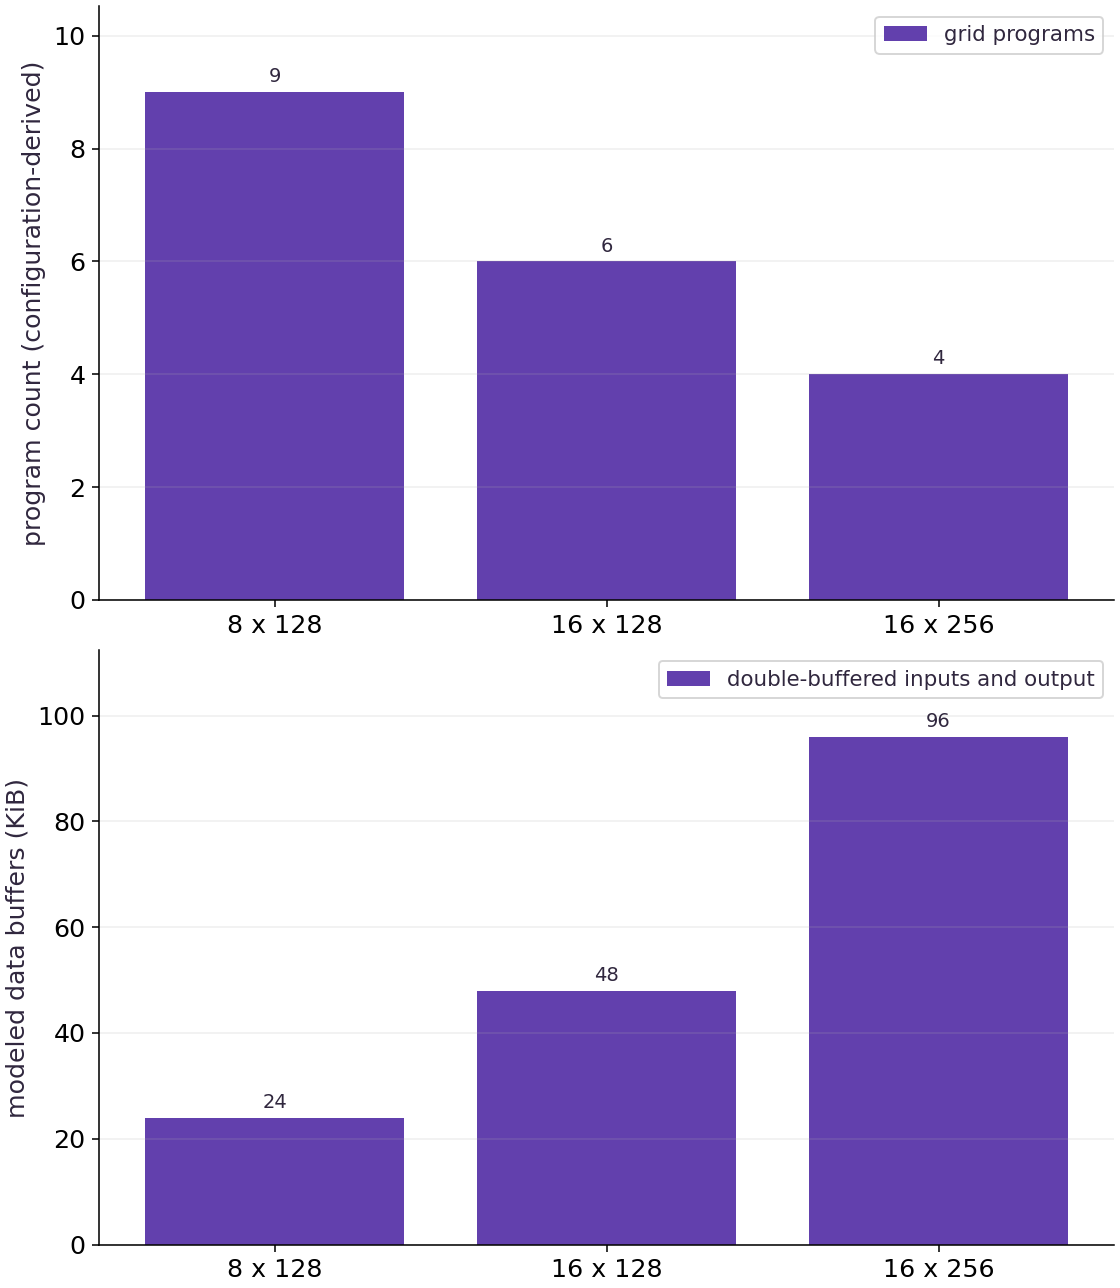

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The first panel shows logical kernel-program counts for three tile shapes on the same $(17,257)$ matrix: $9$, $6$ and $4$. The second panel shows modeled double-buffered data storage: $24$, $48$ and $96$ KiB. These are exact configuration-derived counts, not measured timing or device-memory counters.

The largest tile has fewer programs but four times the modeled data-buffer footprint of the smallest. Its padded element count also rises from $9216$ to $16384$, even though the logical matrix still contains only $4369$ elements.

### Connect it to the computation

Every pictured configuration also runs through the actual Pallas pipeline in CPU simulation and matches the same NumPy result. The figure explains the resource tradeoff that remains after correctness is established.

The footprint omits semaphores, bookkeeping, layout padding, registers and compiler scratch. It cannot establish total VMEM use or speedup. A real TPU trace and synchronized timing are needed to learn whether a larger tile improves reuse enough to offset its costs.

## Change input buffer count without changing the result

Predict: Can adding a third slot to each input change the numerical answer?

In [7]:
three=pipelined_axpy(x,y,buffers=3)
np.testing.assert_allclose(three,reference,rtol=1e-6,atol=1e-6)
np.testing.assert_array_equal(three,buffered)
print("Three-buffer schedule matches the two-buffer result")

Three-buffer schedule matches the two-buffer result


Expected: Two and three input slots produce the same logical result; outputs retain two slots.

More input buffering changes potential overlap and storage, not arithmetic. This installed emitter only supports up to two output slots. A speed benefit remains a target measurement question.

## Check a one-tile pipeline

Predict: What work can be overlapped when there is only one tile?

In [8]:
small_x=jnp.arange(8*128,dtype=jnp.float32).reshape(8,128)/100
small_y=jnp.ones_like(small_x)
small=pipelined_axpy(small_x,small_y)
np.testing.assert_allclose(small,2*np.asarray(small_x)+1,rtol=1e-6,atol=1e-6)
print("Single-tile pipeline checked")

Single-tile pipeline checked


Expected: The one-tile result matches the oracle.

A one-tile pipeline has no next tile with which to overlap its initial fetch. Prologue and drain overhead can dominate small workloads; correctness does not imply a benefit.

## Your exercise

Use a (9,129) random fixture and verify synchronous, double-input-buffered and triple-input-buffered pipelines for both float32 and bfloat16 represented-input contracts. Keep output buffering at two slots.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
rng=np.random.default_rng(23)
for dtype in (jnp.float32,jnp.bfloat16):
    a=jnp.asarray(rng.normal(size=(9,129)),dtype=dtype)
    b=jnp.asarray(rng.normal(size=(9,129)),dtype=dtype)
    expected=(2*a.astype(jnp.float32)+b.astype(jnp.float32)).astype(dtype)
    for buffers,sync in [(2,True),(2,False),(3,False)]:
        result=pipelined_axpy(a,b,buffers=buffers,no_pipelining=sync)
        np.testing.assert_array_equal(np.asarray(result),np.asarray(expected))
print("Changed shape, dtype and schedules verified")

Changed shape, dtype and schedules verified


## Reject an unsupported pipeline tile · Practice

Try a (3,5) block and verify that the pipeline wrapper refuses it rather than using the permissive arithmetic interpreter as a hidden fallback.

Hint: The pipeline lab deliberately uses a conservative TPU-compatible tile family.

In [11]:
# Write your attempt here.

## Reference reasoning

Different wrappers may expose different supported contracts. A narrower explicit contract is safer than implying the generic interpreter established target compatibility.

In [12]:
rejected=False
try:pipelined_axpy(x,y,(3,5))
except ValueError:rejected=True
assert rejected
print("Unsupported pipeline tile rejected")

Unsupported pipeline tile rejected


## Estimate the price of a third input buffer · Challenge

Compute the declared data-buffer footprint for two and three input slots at each tile size, with two output slots in both cases. State at least two omitted memory costs.

Hint: Count two input arrays and one output array separately because their buffer counts differ.

In [13]:
# Write your attempt here.

## Reference reasoning

A third slot for each input increases this limited data-buffer model by one third. Output buffering stays at two slots. The estimate excludes registers, semaphores, compiler scratch and layout effects.

In [14]:
for bm,bn in configurations:
    two=(2*2+2)*bm*bn*4;three=(2*3+2)*bm*bn*4
    assert three*3==two*4
    print("Tile, two/three-input-slot modeled bytes:",(bm,bn),two,three)

Tile, two/three-input-slot modeled bytes: (8, 128) 24576 32768
Tile, two/three-input-slot modeled bytes: (16, 128) 49152 65536
Tile, two/three-input-slot modeled bytes: (16, 256) 98304 131072


## Checkpoint

The three-buffer simulation is correct and has fewer grid programs after a tile change. Can you conclude the TPU version is faster?

1. Yes; program count determines runtime.
2. Yes; simulation latency is the TPU latency.
3. No; padding, local memory and actual target overlap must be measured with synchronized target execution.

## Diagnose

If the buffered result differs from synchronous execution, keep arithmetic and tile geometry fixed while inspecting copies, ownership and synchronization. If the interpreter cannot infer TPU layout on CPU, choose the documented TPU simulation API and label the metadata as simulated. If a larger tile uses fewer programs but more padded work, neither count alone ranks its performance.

## Evidence

Synchronous/buffered CPU simulation agreement, two/three input slots, unchanged output buffering, correctness across tiles and modeled footprint counts. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Keep one numerical operation while changing data movement
- What buffering is trying to overlap
- Use the appropriate interpreter for memory operations
- Use synchronous execution as a debugging comparison
- Count the cost of a tile choice
- Only target measurements can rank pipeline speed

## Primary references

- [Pallas grids and block specifications](https://docs.jax.dev/en/latest/pallas/grid_blockspec.html)
- [Writing TPU kernels: layout and memory restrictions](https://docs.jax.dev/en/latest/pallas/tpu/details.html)
- [TPU pipelining and emit_pipeline](https://docs.jax.dev/en/latest/pallas/tpu/pipelining.html)
- [TPU interpretation is simulation, not target execution](https://docs.jax.dev/en/latest/_autosummary/jax.experimental.pallas.tpu.InterpretParams.html)